# Multiple Q-learning on Individual Treatement Regime : a border study 

In [ ]:
# Librairies 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import os
import sys
sys.path.append("scripts")
from ITR_DataGeneration import data_generation_train, data_generation_test

In [2]:
# ============================================================
# Data generation (train / test)
# ============================================================

# Generate training data
df_train = data_generation_train(800, "Scenario1")

# Covariates + treatment used for variance exploration (optional)
df_train_var = df_train[
    ['X_0','X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8','X_9','A']
]

# Generate independent test data and true optimal treatment
df_test, y_true = data_generation_test(1000, "Scenario1")

# Remove intercept column if present (handled explicitly in design matrix)
del df_test['Intercept']


# ============================================================
# One-stage Q-learning with epsilon-selection
# Treatment space: A ∈ {-1, +1}
# Model: Q(H, A) linear in [1, H, A, A*H]
# ============================================================

# ------------------------------------------------------------
# User-defined settings
# ------------------------------------------------------------

x_cols = [f"X_{j}" for j in range(10)]          # Covariate names
possible_treatments = np.array([-1.0, 1.0])     # Treatment space

epsilon = 1.0                                   # Epsilon tolerance (same scale as Q)
# Optional: relative epsilon
# epsilon = 0.1 * np.std(Z, ddof=1)


# ------------------------------------------------------------
# 1) Fit linear Q-model on training data
# ------------------------------------------------------------

H_tr = df_train[x_cols].to_numpy()                      # Covariates
A_tr = df_train["A"].to_numpy().astype(float).reshape(-1, 1)
Y_tr = df_train["Resp"].to_numpy().astype(float).ravel()

# Design matrix: [1, H, A, A*H]
X_tr = np.column_stack([
    np.ones(H_tr.shape[0]),
    H_tr,
    A_tr.ravel(),
    (A_tr * H_tr)
])

q_model = LinearRegression(fit_intercept=False)
q_model.fit(X_tr, Y_tr)


# ------------------------------------------------------------
# 2) Predict Q-values on test set for each treatment
# ------------------------------------------------------------

H_te = df_test[x_cols].to_numpy()
n_te = H_te.shape[0]

# Matrix of predicted Q-values:
# shape = (n_treatments, n_test)
predicted_matrix = np.zeros((len(possible_treatments), n_te), dtype=float)

for k, a in enumerate(possible_treatments):

    a_vec = np.full((n_te, 1), a, dtype=float)

    X_te = np.column_stack([
        np.ones(n_te),
        H_te,
        a_vec.ravel(),
        (a_vec * H_te)
    ])

    predicted_matrix[k, :] = q_model.predict(X_te)


# ------------------------------------------------------------
# 3) Policy construction
#    - Standard Q-learning (single optimal action)
#    - Epsilon-selection (near-equivalent set)
# ------------------------------------------------------------

Q_m1 = predicted_matrix[0, :]      # Q(H, -1)
Q_p1 = predicted_matrix[1, :]      # Q(H, +1)

Z = Q_p1 - Q_m1                    # Blip function

# Single best treatment (argmax)
idx_best = np.argmax(predicted_matrix, axis=0)
y_pred = possible_treatments[idx_best].astype(float)

# Near-tie region: |blip| ≤ epsilon
near_tie = (np.abs(Z) <= epsilon)

# Recommended treatment set per patient
A_set = np.empty(n_te, dtype=object)

for i in range(n_te):
    if near_tie[i]:
        # Both treatments considered near-equivalent
        A_set[i] = (-1.0, 1.0)
    else:
        # Unique optimal treatment
        A_set[i] = (float(y_pred[i]),)


# ------------------------------------------------------------
# 4) Evaluation metrics
# ------------------------------------------------------------

y_true = np.asarray(y_true).ravel().astype(float)

# Accuracy of single optimal policy
acc_single = np.mean(y_pred == y_true)

# Coverage: true optimal treatment contained in epsilon-set
coverage_eps = np.mean([
    yt in s for yt, s in zip(y_true, A_set)
])

# Accuracy outside near-tie region
acc_outside = (
    np.mean(y_pred[~near_tie] == y_true[~near_tie])
    if (~near_tie).any() else np.nan
)

# Proportion of patients in near-equivalent region
prop_near_tie = near_tie.mean()

print("Single-policy accuracy:", acc_single)
print("Epsilon-set coverage:", coverage_eps)
print("Accuracy outside tie-region:", acc_outside)
print("Proportion near-tie (|blip| ≤ eps):", prop_near_tie)

Single-policy accuracy: 0.96
Epsilon-set coverage: 1.0
Accuracy outside tie-region: 1.0
Proportion near-tie (|blip| ≤ eps): 0.452


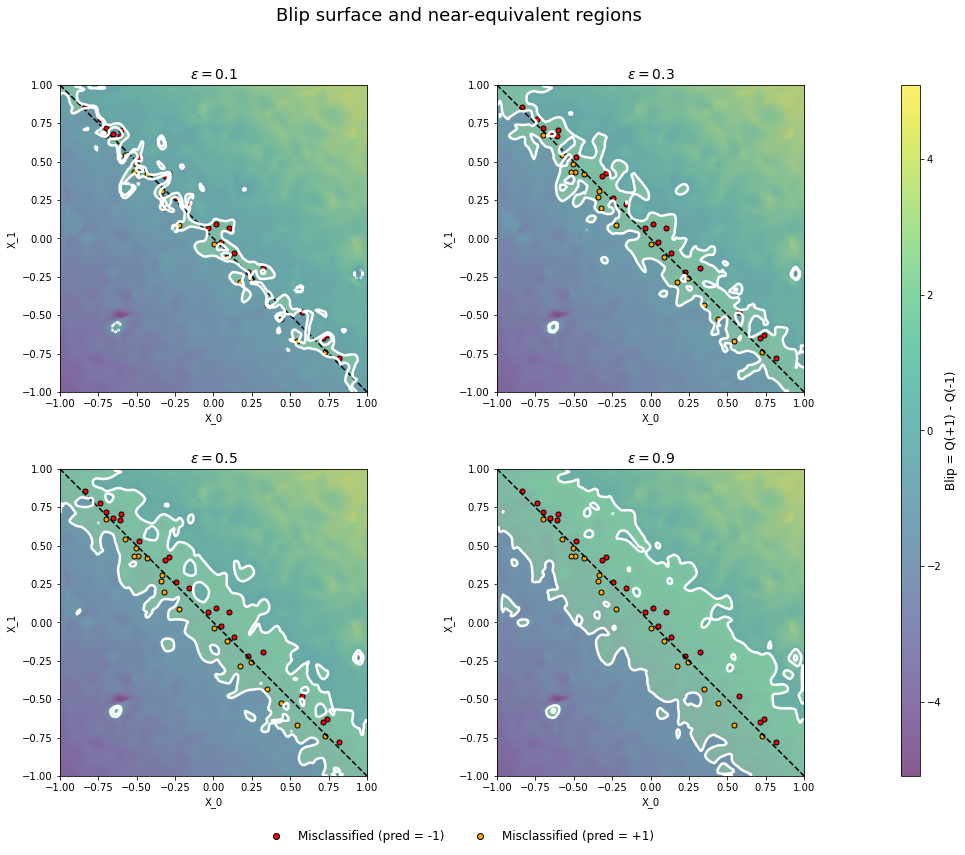

In [ ]:
# ============================================================
# Settings
# ============================================================

eps_list = [0.1, 0.3, 0.5, 0.9]

x = df_test["X_0"].to_numpy()
y = df_test["X_1"].to_numpy()
mis = (y_true != y_pred)

grid_x, grid_y = np.mgrid[-1:1:200j, -1:1:200j]

grid_z = griddata((x, y), Z, (grid_x, grid_y), method="cubic")
grid_z_near = griddata((x, y), Z, (grid_x, grid_y), method="nearest")
grid_z = np.where(np.isnan(grid_z), grid_z_near, grid_z)

v = np.nanmax(np.abs(grid_z))

# ============================================================
# Figure layout (manual control)
# ============================================================

fig = plt.figure(figsize=(16, 12))

# GridSpec with extra column for colorbar
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05],
                      height_ratios=[1, 1],
                      wspace=0.25, hspace=0.25)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1])
]

cax = fig.add_subplot(gs[:, 2])  # colorbar axis

fig.suptitle("Blip surface and near-equivalent regions", fontsize=18, y=0.97)

# ============================================================
# Plot panels
# ============================================================

for i, eps in enumerate(eps_list):

    ax = axes[i]

    hm = ax.imshow(
        grid_z.T,
        extent=(-1, 1, -1, 1),
        origin="lower",
        cmap="viridis",
        alpha=0.65,
        vmin=-v,
        vmax=v
    )

    ax.plot([-1, 1], [1, -1], "k--", linewidth=1.5)

    ax.contour(grid_x, grid_y, np.abs(grid_z),
               levels=[eps], colors="white", linewidths=2.5)

    tie_mask = (np.abs(grid_z) <= eps).astype(float)
    ax.imshow(tie_mask.T, extent=(-1, 1, -1, 1),
              origin="lower", alpha=0.12)

    ax.scatter(x[mis & (y_pred == -1)],
               y[mis & (y_pred == -1)],
               color="red", edgecolor="k", s=25)

    ax.scatter(x[mis & (y_pred == 1)],
               y[mis & (y_pred == 1)],
               color="orange", edgecolor="k", s=25)

    ax.set_title(f"$\\varepsilon = {eps}$", fontsize=14)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("X_0")
    ax.set_ylabel("X_1")

# ============================================================
# Colorbar (clean, outside grid)
# ============================================================

cbar = fig.colorbar(hm, cax=cax)
cbar.set_label("Blip = Q(+1) - Q(-1)", fontsize=12)

# ============================================================
# Bottom legend (no overlap)
# ============================================================

legend_elements = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor="red", markeredgecolor="k",
           markersize=6, label="Misclassified (pred = -1)"),
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor="orange", markeredgecolor="k",
           markersize=6, label="Misclassified (pred = +1)")
]
fig.legend(handles=legend_elements,
           loc="lower center",
           ncol=2,
           frameon=False,
           fontsize=12,
           bbox_to_anchor=(0.5, -0.01))  
           
plt.subplots_adjust(bottom=0.12) 

plt.subplots_adjust(bottom=0.08)

os.makedirs("./results", exist_ok=True)

plt.savefig(
    "./results/blip_surface_near_equivalent_regions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()